  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  
<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null

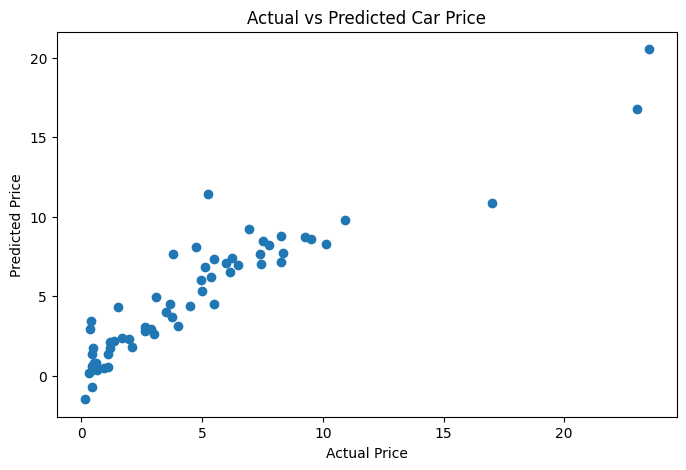

Predicted Car Price: 5.777714802144361


C:\Users\shiva\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [7]:



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Dataset

Car_Data = pd.read_csv(r"C:\Users\shiva\Downloads\archive (4)\car data.csv")


print(Car_Data.head())


print(Car_Data.info())
print(Car_Data.isnull().sum())


Car_Data['Car_Age'] = 2026 - Car_Data['Year']

# Drop unwanted columns
Car_Data.drop(['Year', 'Car_Name'], axis=1, inplace=True)


le = LabelEncoder()

Car_Data['Fuel_Type'] = le.fit_transform(Car_Data['Fuel_Type'])
Car_Data['Selling_type'] = le.fit_transform(Car_Data['Selling_type'])
Car_Data['Transmission'] = le.fit_transform(Car_Data['Transmission'])


# X and y

X = Car_Data.drop('Selling_Price', axis=1)
y = Car_Data['Selling_Price']


# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Train Model

model = LinearRegression()
model.fit(X_train, y_train)


prediction = model.predict(X_test)


print("MAE :", mean_absolute_error(y_test, prediction))
print("MSE :", mean_squared_error(y_test, prediction))
print("RMSE:", np.sqrt(mean_squared_error(y_test, prediction)))
print("R2 Score:", r2_score(y_test, prediction))


plt.figure(figsize=(8,5))
plt.scatter(y_test, prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Price")
plt.show()



sample = [[45000, 0, 0, 0, 1, 5]]

# Features order:
# Present_Price
# Kms_Driven
# Fuel_Type
# Selling_type
# Transmission
# Owner
# Car_Age

sample = [[5.59, 27000, 2, 0, 1, 0, 7]]

pred_price = model.predict(sample)

print("Predicted Car Price:", pred_price[0])